In [2]:
import os
import json
import random
from tqdm import tqdm

In [3]:
with open("/workspace/datasets/prompts.json", "r") as f:
    prompts = json.load(f)

In [4]:
len(prompts)

35666

In [5]:
lambdas = [lambda x: json.loads(x.split("```json")[1].replace("```", "")), 
           lambda x: json.loads('[' + x.strip().strip(',') + ']'), 
           lambda x: json.loads('[' + x.strip().strip(",")), 
           lambda x: json.loads(x.strip().strip(",") + ']')]

In [6]:
processed_prompts = {}
count = 0
for key in prompts.keys():
    loaded_dict = None
    for lambd in lambdas:
        try:
            loaded_dict = lambd(prompts[key])
            processed_prompts[key] = loaded_dict
        except Exception as e:
            pass

    if not loaded_dict:
        # print(key)
        count += 1
            
print(count)

555


In [7]:
len(processed_prompts.keys())

35114

In [8]:
set([len(processed_prompts[key]) for key in processed_prompts.keys()])

{0, 1, 9, 10, 11, 12, 13}

In [9]:
with open("processed_prompts.json", "w") as f:
    json.dump(processed_prompts, f)

In [10]:
len(processed_prompts)

35114

In [11]:
data = []
failed = []
for video_id in tqdm(os.listdir("/workspace/datasets/processed_celebs_data/")):
    optical_images = []
    for img in os.listdir(os.path.join("/workspace/datasets/processed_celebs_data/", video_id)):
        if "optical" in img:
            optical_images.append(img)
    try:
        selected_images = random.choices(optical_images, k=min(20, len(optical_images)))
        available_prompts = processed_prompts[video_id]
        selected_prompts = random.choices(available_prompts, k=min(4, len(available_prompts)))
        for img in selected_images:
            prev_img = img.split(".")[0].split("_")[-2] + ".jpg"
            curr_img = img.split(".")[0].split("_")[-1] + ".jpg"
            prompt = random.choice(selected_prompts)["prompt"]
            negative_prompt = random.choice(selected_prompts)["negative_prompt"]
            if type(negative_prompt) == list:
                negative_prompt = ", ".join(negative_prompt)
            elif negative_prompt == None:
                negative_prompt = ""
            data.append({"video_id": video_id, 
                        "prompt": prompt, 
                        "negative_prompt": negative_prompt, 
                        "prev_img_path": os.path.join("/workspace/datasets/processed_celebs_data/", video_id, prev_img), 
                        "curr_img_path": os.path.join("/workspace/datasets/processed_celebs_data/", video_id, curr_img),
                        "optical_flow_path": os.path.join("/workspace/datasets/processed_celebs_data/", video_id, img)})
    except Exception as e:
        failed.append(video_id)
        continue


  1%|          | 394/35666 [00:00<00:08, 3934.72it/s]

100%|██████████| 35666/35666 [00:06<00:00, 5338.48it/s]


In [12]:
len(data), len(failed)

(656420, 2824)

In [13]:
data[2]

{'video_id': '--Jiv5iYqT8_0',
 'prompt': 'man with gray hair and bags under eyes, bald head, talking in a dimly lit room, close-up, serious expression, natural colors, indoor setting, soft lighting, soft focus, natural colors',
 'negative_prompt': 'blurry, washed out, low resolution, poor focus',
 'prev_img_path': '/workspace/datasets/processed_celebs_data/--Jiv5iYqT8_0/58.jpg',
 'curr_img_path': '/workspace/datasets/processed_celebs_data/--Jiv5iYqT8_0/67.jpg',
 'optical_flow_path': '/workspace/datasets/processed_celebs_data/--Jiv5iYqT8_0/optical_flow_58_67.jpg'}

In [14]:
data[4]

{'video_id': '--Jiv5iYqT8_0',
 'prompt': 'man with gray hair and bags under eyes, bald head, talking in a dark room, low light, close-up, focused expression, serious demeanor',
 'negative_prompt': 'blurry, low resolution, low light, artificial lighting',
 'prev_img_path': '/workspace/datasets/processed_celebs_data/--Jiv5iYqT8_0/37.jpg',
 'curr_img_path': '/workspace/datasets/processed_celebs_data/--Jiv5iYqT8_0/42.jpg',
 'optical_flow_path': '/workspace/datasets/processed_celebs_data/--Jiv5iYqT8_0/optical_flow_37_42.jpg'}

In [15]:
with open("temporalnet2_data.jsonl", "w") as f:
    for d in data:
        json.dump(d, f)
        f.write("\n")

In [14]:
img.split(".")[0].split("_")[-1], img.split(".")[0].split("_")[-2]

('126', '125')

In [ ]:
import collections
collections.Counter(diff)

In [15]:
img

'optical_flow_125_126.jpg'

In [17]:
from PIL import Image
img = Image.open("/home/user/datasets/processed_celebs_data/TqNaJxRC9NM_1/optical_flow_49_51.jpg")



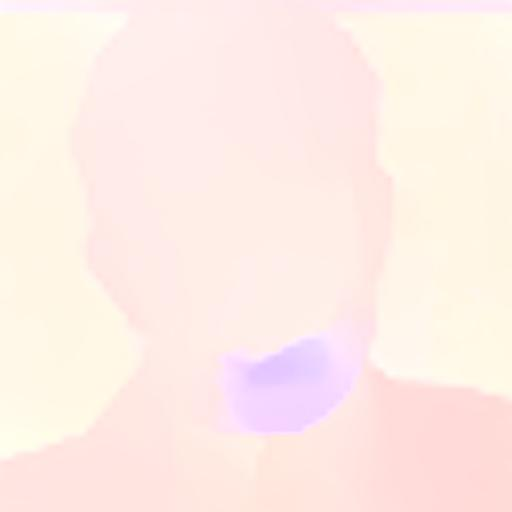

In [18]:
from IPython.display import Image
Image(filename='/home/user/datasets/processed_celebs_data/TqNaJxRC9NM_1/optical_flow_49_51.jpg') 

In [ ]:
random.choices(list(range(len(data))), k=2)

In [19]:
data[155318]

{'video_id': '3iRl9GRYVXY_3_0',
 'prompt': 'bald man with bushy eyebrows and pointy nose, wearing a Hawaiian shirt, sitting at a table, talking, focused expression, warm indoor lighting, shallow depth of field, realistic style',
 'negative_prompt': 'blurry, low resolution, watermark, text',
 'prev_img_path': '/home/user/datasets/processed_celebs_data/3iRl9GRYVXY_3_0/66.jpg',
 'curr_img_path': '/home/user/datasets/processed_celebs_data/3iRl9GRYVXY_3_0/70.jpg',
 'optical_flow_path': '/home/user/datasets/processed_celebs_data/3iRl9GRYVXY_3_0/optical_flow_66_70.jpg'}

In [1]:
from IPython.display import Image

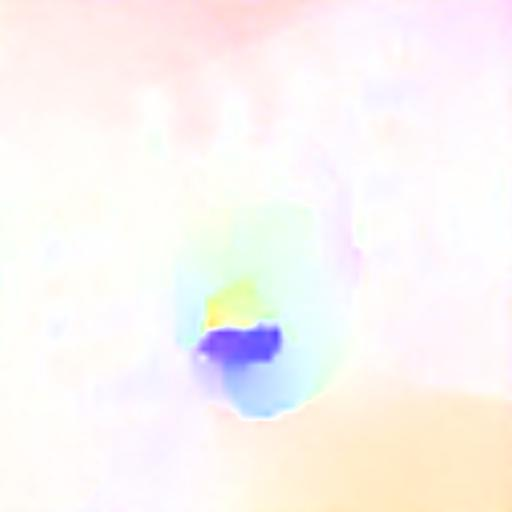

In [3]:
Image("/workspace/datasets/processed_celebs_data/3iRl9GRYVXY_3_0/optical_flow_66_70.jpg")

In [4]:
import torch
from torchvision.models.optical_flow import raft_small, Raft_Small_Weights
from torchvision.io import read_image
from torchvision.utils import flow_to_image
import numpy as np
from PIL import Image as PILImage
from IPython.display import Image
import io

def apply_optical_flow_and_display(img1_path, img2_path, device='cuda' if torch.cuda.is_available() else 'cpu'):
    """
    Apply optical flow between two images using RAFT model and display the result.
    
    Args:
        img1_path: Path to first image
        img2_path: Path to second image
        device: Device to run the model on ('cuda' or 'cpu')
    
    Returns:
        IPython.display.Image object
    """
    # Load the RAFT model
    weights = Raft_Small_Weights.DEFAULT
    model = raft_small(weights=weights).to(device)
    model.eval()
    
    # Load and preprocess images
    img1 = read_image(img1_path)
    img2 = read_image(img2_path)
    
    # Preprocess
    transforms = weights.transforms()
    img1_batch, img2_batch = transforms(img1, img2)
    img1_batch = img1_batch.unsqueeze(0).to(device)
    img2_batch = img2_batch.unsqueeze(0).to(device)
    
    # Compute optical flow
    with torch.no_grad():
        flow_predictions = model(img1_batch, img2_batch)
        flow = flow_predictions[-1][0]  # Keep as tensor (2, H, W)
    
    # Convert flow to RGB using torchvision's built-in function
    flow_rgb = flow_to_image(flow).cpu().numpy()
    
    # Convert from (3, H, W) to (H, W, 3)
    flow_rgb = np.transpose(flow_rgb, (1, 2, 0))
    
    # Save to temporary buffer
    buf = io.BytesIO()
    PILImage.fromarray(flow_rgb).save(buf, format='PNG')
    buf.seek(0)
    
    # Display using IPython.display.Image
    return Image(data=buf.read())

# Example usage:
# apply_optical_flow_and_display('/path/to/image1.jpg', '/path/to/image2.jpg')


Downloading: "https://download.pytorch.org/models/raft_small_C_T_V2-01064c6d.pth" to /root/.cache/torch/hub/checkpoints/raft_small_C_T_V2-01064c6d.pth


100%|██████████| 3.82M/3.82M [00:00<00:00, 30.4MB/s]


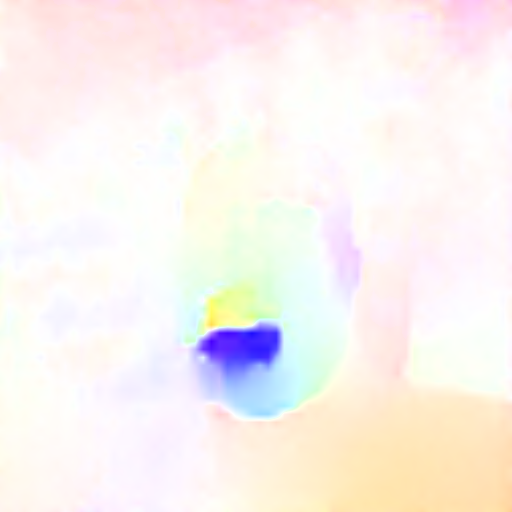

In [5]:
# Test the function with existing data
apply_optical_flow_and_display("/workspace/datasets/processed_celebs_data/3iRl9GRYVXY_3_0/66.jpg", "/workspace/datasets/processed_celebs_data/3iRl9GRYVXY_3_0/70.jpg")
